# Thực hành Buổi 11+12 (bản gộp): Trực quan hóa, Mô hình dự báo đơn giản & Dashboard BI

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Matplotlib, Seaborn, Scikit-Learn · BI tools: Power BI / Looker Studio (Data Studio)

**Đầu vào ➔ Đầu ra:** dataset giao dịch sạch (Bài 6) ➔ bộ biểu đồ Python + mô hình dự báo đơn giản + **data mẫu để học viên TỰ XÂY dashboard BI**

| Phần | Nội dung | Thời gian |
|:---|:---|:---|
| A | Trực quan hóa dữ liệu bằng Python (Matplotlib, Seaborn) — dựng "dashboard tĩnh" 1 trang | 15 phút |
| B | Xây dựng 2 mô hình dự báo đơn giản: doanh thu ngày mai & khách hàng rời bỏ | 15 phút |
| C | Xuất **data mẫu** + số kiểm chứng ➔ **ĐỀ BÀI: tự xây dashboard** trên Power BI / Looker Studio | 10 phút + tự làm |

> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb`. Bản đầy đủ của hai chủ đề này nằm ở `lab11/` (Power BI chuyên sâu, DAX, star schema) và `lab12/` (ML Pipeline bài bản) — bản gộp giữ phần cốt lõi và dồn trọng tâm vào việc **học viên tự tay dựng dashboard**.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

RAW = Path("../data/raw"); PROCESSED = Path("../data/processed")
DASHBOARD = PROCESSED / "dashboard"; DASHBOARD.mkdir(parents=True, exist_ok=True)

tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
kh = pd.read_csv(RAW / "customer_churn.csv")
tx_ht = tx[tx["status"] == "HOAN_TAT"].copy()
tx_ht["thang"] = tx_ht["ts"].dt.to_period("M").astype(str)
print(f"Giao dịch hoàn tất: {len(tx_ht):,} | Khách hàng: {len(kh):,}")

Giao dịch hoàn tất: 57,882 | Khách hàng: 8,000


---
## PHẦN A — TRỰC QUAN HÓA DỮ LIỆU BẰNG PYTHON (15 phút)

Bốn nguyên tắc trước khi vẽ bất cứ thứ gì:

| Nguyên tắc | Nghĩa là |
|:---|:---|
| **Mỗi biểu đồ một câu hỏi** | xu hướng ➔ đường; cơ cấu ➔ cột ngang; phân phối ➔ box/hist; nhịp 2 chiều ➔ nhiệt đồ |
| **Tiêu đề là KẾT LUẬN** | "Thực phẩm dẫn đầu doanh thu" thay vì "Doanh thu theo ngành" |
| **Ít màu, màu có nghĩa** | 3–4 màu; một đối tượng = một màu ở mọi biểu đồ |
| **Bỏ mực thừa** | lưới mờ, không viền thừa, không 3D — mực chỉ dành cho dữ liệu |

Ô dưới đây ghép 4 biểu đồ thành **một trang "dashboard tĩnh"** — chính là bản nháp giấy (wireframe) cho dashboard BI mà bạn sẽ dựng ở Phần C:

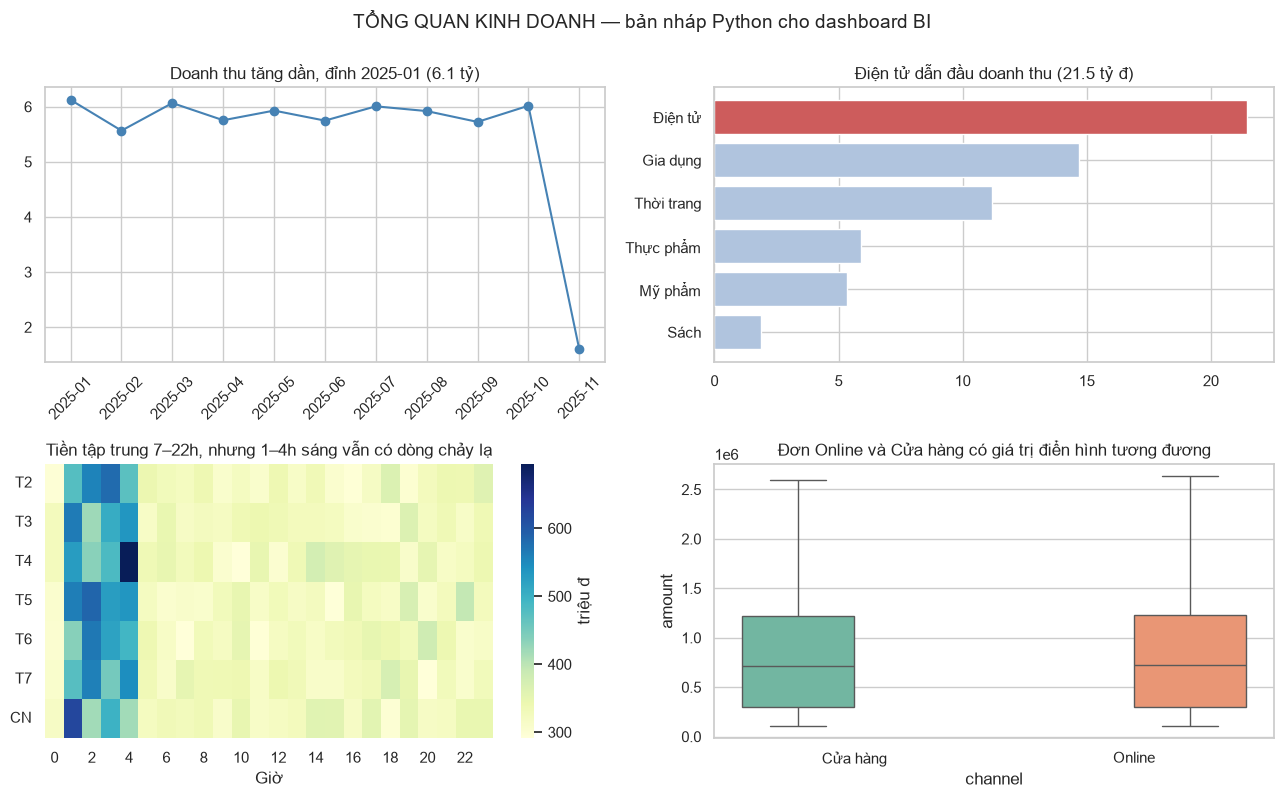

Đã lưu bản nháp: ..\data\processed\dashboard_python.png


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("TỔNG QUAN KINH DOANH — bản nháp Python cho dashboard BI", fontsize=14, y=0.995)

# (1) XU HƯỚNG — đường
dt_thang = tx_ht.groupby("thang")["amount"].sum() / 1e9
axes[0, 0].plot(dt_thang.index, dt_thang.values, marker="o", color="steelblue")
axes[0, 0].set_title(f"Doanh thu tăng dần, đỉnh {dt_thang.idxmax()} ({dt_thang.max():.1f} tỷ)")
axes[0, 0].tick_params(axis="x", rotation=45)

# (2) CƠ CẤU — cột ngang
nganh = tx_ht.groupby("category", observed=True)["amount"].sum().sort_values() / 1e9
axes[0, 1].barh(nganh.index, nganh.values,
                color=["indianred" if i == len(nganh) - 1 else "lightsteelblue"
                       for i in range(len(nganh))])
axes[0, 1].set_title(f"{nganh.idxmax()} dẫn đầu doanh thu ({nganh.max():.1f} tỷ đ)")

# (3) NHỊP 2 CHIỀU — nhiệt đồ
nhip = (tx_ht.assign(gio=tx_ht["ts"].dt.hour, thu=tx_ht["ts"].dt.dayofweek)
        .pivot_table(index="thu", columns="gio", values="amount", aggfunc="sum") / 1e6)
sns.heatmap(nhip, cmap="YlGnBu", ax=axes[1, 0], cbar_kws={"label": "triệu đ"})
axes[1, 0].set_yticklabels(["T2", "T3", "T4", "T5", "T6", "T7", "CN"], rotation=0)
axes[1, 0].set_title("Tiền tập trung 7–22h, nhưng 1–4h sáng vẫn có dòng chảy lạ")
axes[1, 0].set_xlabel("Giờ"); axes[1, 0].set_ylabel("")

# (4) PHÂN PHỐI — box theo nhóm
sns.boxplot(data=tx_ht, x="channel", y="amount", ax=axes[1, 1], showfliers=False,
            hue="channel", legend=False, palette="Set2")
axes[1, 1].set_title("Đơn Online và Cửa hàng có giá trị điển hình tương đương")

plt.tight_layout()
fig.savefig(PROCESSED / "dashboard_python.png", bbox_inches="tight")
plt.show()
print("Đã lưu bản nháp:", PROCESSED / "dashboard_python.png")

> **Python vs BI tool:** Matplotlib/Seaborn cho bạn kiểm soát tuyệt đối và tự động hóa được (chạy lại là ra báo cáo mới), nhưng ảnh là **tĩnh**. BI tool (Power BI, Looker Studio) cho **tương tác** — slicer, drill-down, tooltip — và người không biết code cũng tự khám phá được. Người phân tích giỏi dùng cả hai: Python để thăm dò và làm nháp, BI để giao cho người ra quyết định.

---
## PHẦN B — HAI MÔ HÌNH DỰ BÁO ĐƠN GIẢN (15 phút)

### B1. Dự báo doanh thu ngày — hồi quy tuyến tính trên đặc trưng lịch

Dùng bộ dữ liệu nhu cầu thị trường `market_demand.csv` (3 năm, có trend + mùa vụ — cùng bộ với Bài 10; ô dưới **tự sinh nếu thiếu**). Mô hình đơn giản nhất có thể mà vẫn nghiêm túc: doanh thu ngày = **xu hướng** (số thứ tự ngày) + **hiệu ứng thứ trong tuần** (7 biến one-hot). Giấu 30 ngày cuối làm tập test — chia **theo thời gian**, không trộn ngẫu nhiên.

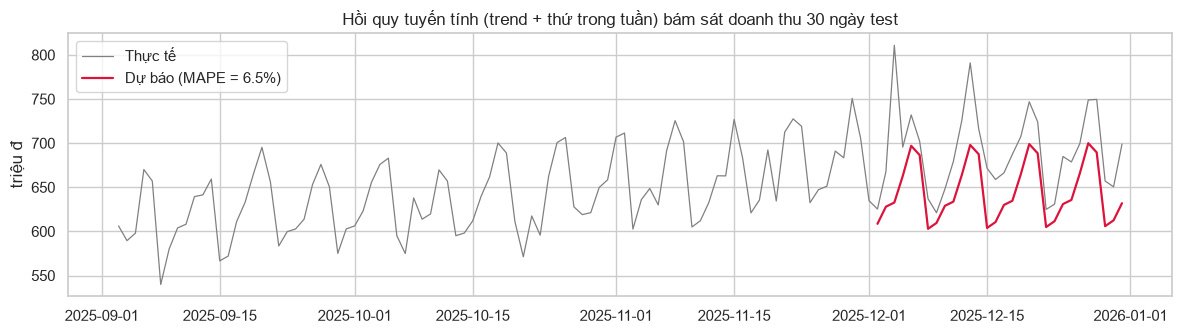

MAPE trên 30 ngày test: 6.5%
Xu hướng học được: +0.14 triệu đ/ngày (cấy sẵn +0.16) | Thứ mạnh nhất: T7 (+51 triệu đ so với mức chung)
Mô hình tuyến tính là VẠCH XUẤT PHÁT — Bài 10 (SARIMA) cho thấy mô hình chuỗi thời gian chuyên dụng làm được gì hơn.


In [3]:
from sklearn.linear_model import LinearRegression

if not (RAW / "market_demand.csv").exists():        # sinh y hệt Bài 10 (seed=42)
    rng = np.random.default_rng(42)
    lich = pd.date_range("2023-01-01", "2025-12-31", freq="D")
    t = np.arange(len(lich))
    doanh_thu_md = (480 + 0.16 * t
                    + np.array([-38, -30, -16, -6, 20, 58, 44])[lich.dayofweek]
                    + 42 * np.sin(2 * np.pi * (t - 300) / 365.25)
                    + rng.normal(0, 18, len(lich)))
    i_km = rng.choice(len(lich), 8, replace=False)
    doanh_thu_md[i_km] += rng.uniform(90, 160, 8)
    so_don_md = (doanh_thu_md * 1.9 + rng.normal(0, 25, len(lich))).round().astype(int)
    pd.DataFrame({"date": lich.strftime("%Y-%m-%d"), "orders": so_don_md,
                  "revenue_trieu": doanh_thu_md.round(1)}
                 ).to_csv(RAW / "market_demand.csv", index=False)

ngay = pd.read_csv(RAW / "market_demand.csv", parse_dates=["date"],
                   index_col="date").asfreq("D")["revenue_trieu"]

TEN_THU = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
X = pd.get_dummies(pd.DataFrame({
    "t": np.arange(len(ngay)),
    "thu": [TEN_THU[i] for i in ngay.index.dayofweek],
}), columns=["thu"], dtype=int)
y = ngay.values

X_train, X_test = X.iloc[:-30], X.iloc[-30:]
y_train, y_test = y[:-30], y[-30:]

mo_hinh = LinearRegression().fit(X_train, y_train)
du_bao = mo_hinh.predict(X_test)
mape = np.mean(np.abs(y_test - du_bao) / y_test) * 100

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ngay.index[-120:], y[-120:], lw=0.9, color="gray", label="Thực tế")
ax.plot(ngay.index[-30:], du_bao, lw=1.6, color="crimson",
        label=f"Dự báo (MAPE = {mape:.1f}%)")
ax.set_title("Hồi quy tuyến tính (trend + thứ trong tuần) bám sát doanh thu 30 ngày test")
ax.set_ylabel("triệu đ"); ax.legend()
plt.tight_layout(); plt.show()

he_so_thu = pd.Series(mo_hinh.coef_[1:], index=[c[4:] for c in X.columns[1:]])
print(f"MAPE trên 30 ngày test: {mape:.1f}%")
print(f"Xu hướng học được: {mo_hinh.coef_[0]:+.2f} triệu đ/ngày (cấy sẵn +0.16)"
      f" | Thứ mạnh nhất: {he_so_thu.idxmax()} ({he_so_thu.max():+.0f} triệu đ so với mức chung)")
print("Mô hình tuyến tính là VẠCH XUẤT PHÁT — Bài 10 (SARIMA) cho thấy mô hình chuỗi thời gian chuyên dụng làm được gì hơn.")

### B2. Dự đoán khách hàng rời bỏ — Logistic Regression trong một Pipeline

Phiên bản 10 dòng của Bài 12: ghép 3 chỉ số RFM vào hồ sơ khách, đóng gói tiền xử lý + mô hình vào một `Pipeline`, chấm bằng ROC-AUC (0,5 = đoán mò). Kết quả của mô hình này chính là **một ô KPI trên dashboard**: "bao nhiêu % khách đang có nguy cơ rời bỏ".

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

moc = tx_ht["ts"].max() + pd.Timedelta(days=1)
rfm = (tx_ht.groupby("customer_id")
       .agg(recency=("ts", lambda s: (moc - s.max()).days),
            frequency=("transaction_id", "size"), monetary=("amount", "sum")))
du_lieu = kh.merge(rfm, left_on="customer_id", right_index=True, how="left") \
            .fillna({"recency": 999, "frequency": 0, "monetary": 0})

X = du_lieu.drop(columns=["customer_id", "churn"]); y = du_lieu["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)
pipe = Pipeline([
    ("tien_xu_ly", ColumnTransformer([
        ("so", StandardScaler(), ["age", "tenure_months", "support_tickets",
                                  "recency", "frequency", "monetary"]),
        ("phan_loai", OneHotEncoder(handle_unknown="ignore"), ["gender", "city"]),
    ])),
    ("mo_hinh", LogisticRegression(max_iter=1000, random_state=42)),
]).fit(X_tr, y_tr)

xac_suat = pipe.predict_proba(X_te)[:, 1]
print(f"ROC-AUC dự đoán churn: {roc_auc_score(y_te, xac_suat):.3f}  (đoán mò = 0.500)")
ty_le_nguy_co = (pipe.predict_proba(X)[:, 1] >= 0.5).mean()
print(f"KPI cho dashboard: {ty_le_nguy_co:.1%} khách hàng đang bị gắn cờ nguy cơ rời bỏ")

ROC-AUC dự đoán churn: 0.751  (đoán mò = 0.500)
KPI cho dashboard: 25.1% khách hàng đang bị gắn cờ nguy cơ rời bỏ


---
## PHẦN C — DATA MẪU & ĐỀ BÀI: TỰ XÂY DASHBOARD BI (10 phút chuẩn bị + tự làm)

Ô dưới đây xuất **2 bảng data mẫu** (định dạng phẳng, một bảng sự kiện + một bảng khách hàng — nạp thẳng được vào cả Power BI lẫn Looker Studio) và **bảng số kiểm chứng**:

| Tệp | Nội dung | Dùng cho |
|:---|:---|:---|
| `ban_hang_theo_ngay.csv` | doanh thu/chi phí/số đơn theo ngày × ngành × chi nhánh × kênh | mọi biểu đồ bán hàng |
| `khach_hang.csv` | 8.000 khách: nhân khẩu, RFM, phân khúc, churn, **xác suất churn từ mô hình B2** | trang khách hàng |
| `so_kiem_chung.csv` | các con số dashboard PHẢI ra đúng | đối chiếu |

In [5]:
ban_hang = (tx_ht.assign(date=tx_ht["ts"].dt.date.astype(str))
            .groupby(["date", "category", "branch", "channel"], observed=True)
            .agg(so_don=("transaction_id", "size"), so_khach=("customer_id", "nunique"),
                 doanh_thu=("amount", "sum"), chi_phi=("cost", "sum"))
            .round(0).reset_index())

phan_khuc = np.select(
    [(rfm["recency"] <= 30) & (rfm["frequency"] >= 10),
     (rfm["recency"] <= 30), (rfm["recency"] > 120)],
    ["Khách VIP", "Đang hoạt động", "Đã ngủ đông"], "Trung bình")
khach_hang = (kh.merge(rfm.assign(phan_khuc=phan_khuc), left_on="customer_id",
                       right_index=True, how="left")
              .fillna({"recency": 999, "frequency": 0, "monetary": 0,
                       "phan_khuc": "Chưa mua"}))
khach_hang["xac_suat_churn"] = pipe.predict_proba(
    khach_hang[X.columns])[:, 1].round(3)

so_kiem_chung = pd.DataFrame([
    ["Tổng doanh thu",        f"{ban_hang['doanh_thu'].sum():,.0f} đ"],
    ["Tổng số đơn",           f"{ban_hang['so_don'].sum():,}"],
    ["Biên LN gộp",           f"{1 - ban_hang['chi_phi'].sum()/ban_hang['doanh_thu'].sum():.1%}"],
    ["Ngành dẫn đầu",         ban_hang.groupby('category')['doanh_thu'].sum().idxmax()],
    ["Tỷ lệ churn thực tế",   f"{khach_hang['churn'].mean():.1%}"],
    ["Khách nguy cơ (mô hình)", f"{(khach_hang['xac_suat_churn'] >= 0.5).mean():.1%}"],
], columns=["Chỉ số", "Giá trị PHẢI ra"])

for ten, bang in [("ban_hang_theo_ngay", ban_hang), ("khach_hang", khach_hang),
                  ("so_kiem_chung", so_kiem_chung)]:
    bang.to_csv(DASHBOARD / f"{ten}.csv", index=False, encoding="utf-8-sig")
    print(f"  {ten}.csv : {len(bang):,} dòng")
print("\nData mẫu nằm trong:", DASHBOARD.resolve())
print(so_kiem_chung.to_string(index=False))

  ban_hang_theo_ngay.csv : 16,529 dòng
  khach_hang.csv : 8,000 dòng
  so_kiem_chung.csv : 6 dòng

Data mẫu nằm trong: D:\DataAnalytics\data\processed\dashboard
                 Chỉ số  Giá trị PHẢI ra
         Tổng doanh thu 60,455,690,548 đ
            Tổng số đơn           57,882
            Biên LN gộp            27.9%
          Ngành dẫn đầu          Điện tử
    Tỷ lệ churn thực tế            35.1%
Khách nguy cơ (mô hình)            25.2%


### ĐỀ BÀI — TỰ XÂY DASHBOARD (nộp sản phẩm, chấm theo rubric trong tài liệu)

Chọn **một trong hai** công cụ (chi tiết từng bước trong `Buoi_11_12_Gop_Huong_Dan_Thuc_Hanh.docx`):

- **Power BI Desktop** (Windows): Get Data ➔ Text/CSV ➔ nạp 2 tệp data mẫu;
- **Looker Studio / Data Studio** (miễn phí, chạy trên web, mọi hệ điều hành): upload 2 CSV lên Google Sheets ➔ lookerstudio.google.com ➔ Create ➔ Data source ➔ Google Sheets.

**Yêu cầu tối thiểu (bắt buộc đủ 7 mục):**

1. Trang **Tổng quan bán hàng**: 4 thẻ KPI (Tổng doanh thu · Biên LN gộp · Tổng số đơn · Tỷ lệ churn);
2. Một biểu đồ **đường** doanh thu theo thời gian;
3. Một biểu đồ **cột** doanh thu theo ngành hàng;
4. Ít nhất **2 bộ lọc** (slicer/control): khoảng thời gian + kênh hoặc chi nhánh — lọc phải tác động đến MỌI biểu đồ;
5. Trang **Khách hàng**: biểu đồ churn theo phân khúc + bảng top 20 khách có `xac_suat_churn` cao nhất và `monetary` lớn nhất (danh sách "gọi giữ chân trước");
6. **Tiêu đề mỗi biểu đồ là một kết luận** (không đặt tên trục làm tiêu đề);
7. Mọi con số KPI **khớp `so_kiem_chung.csv`** — lệch là sai bộ lọc hoặc sai phép gộp.

**Nộp:** file `.pbix` (Power BI) **hoặc** link chia sẻ Looker Studio (chế độ Anyone with the link can view) + 1 ảnh chụp mỗi trang.

---
## TỔNG KẾT

| Phần | Sản phẩm | Bài đầy đủ để đào sâu |
|:---|:---|:---|
| A | Bản nháp dashboard bằng Python (`dashboard_python.png`) | Bài 8 (KPI), nguyên tắc viz |
| B | 2 mô hình dự báo đơn giản: doanh thu (MAPE) + churn (ROC-AUC) | Bài 10 (SARIMA), Bài 12 (Pipeline bài bản) |
| C | Data mẫu + số kiểm chứng + **dashboard tự xây** | Bài 11 (star schema, DAX chuyên sâu) |

---
# BÀI TẬP VỀ NHÀ

#### Bài tập 1: Thêm vào `ban_hang_theo_ngay.csv` cột `du_bao_doanh_thu` — dùng mô hình B1 dự báo 14 ngày kế tiếp (sau ngày cuối của dữ liệu), xuất lại CSV và vẽ lớp dự báo đó lên biểu đồ đường trong dashboard của bạn (Power BI/Looker Studio đều vẽ được 2 chuỗi trên cùng trục).

In [6]:
# --- BÀI TẬP 1 ---


#### Bài tập 2: Trong dashboard, thêm trang thứ ba "Vận hành" trả lời câu hỏi: khung giờ × thứ nào bán mạnh nhất, chi nhánh nào có AOV cao nhất? (gợi ý: pivot heatmap của Phần A chính là wireframe). Chụp ảnh nộp kèm.

In [7]:
# --- BÀI TẬP 2 ---
